In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [13]:
df = pd.read_csv('Teen_Mental_Health_Dataset.csv')


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       1200 non-null   int64  
 1   gender                    1200 non-null   object 
 2   daily_social_media_hours  1200 non-null   float64
 3   platform_usage            1200 non-null   object 
 4   sleep_hours               1200 non-null   float64
 5   screen_time_before_sleep  1200 non-null   float64
 6   academic_performance      1200 non-null   float64
 7   physical_activity         1200 non-null   float64
 8   social_interaction_level  1200 non-null   object 
 9   stress_level              1200 non-null   int64  
 10  anxiety_level             1200 non-null   int64  
 11  addiction_level           1200 non-null   int64  
 12  depression_label          1200 non-null   int64  
dtypes: float64(5), int64(5), object(3)
memory usage: 122.0+ KB


In [15]:
df

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,18,female,6.8,Instagram,6.6,2.0,2.76,1.0,low,3,4,4,0
1196,16,male,2.3,Both,8.0,1.9,2.12,0.4,high,7,4,4,0
1197,14,female,1.7,Both,8.7,0.7,3.98,0.8,high,1,1,1,0
1198,15,male,3.9,Both,8.5,2.1,3.19,0.6,high,7,9,9,0


In [16]:
df.dtypes

age                           int64
gender                       object
daily_social_media_hours    float64
platform_usage               object
sleep_hours                 float64
screen_time_before_sleep    float64
academic_performance        float64
physical_activity           float64
social_interaction_level     object
stress_level                  int64
anxiety_level                 int64
addiction_level               int64
depression_label              int64
dtype: object

In [17]:
df.describe()

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,stress_level,anxiety_level,addiction_level,depression_label
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,15.928333,4.536667,6.449417,1.740333,2.990383,1.014500,5.445833,5.636667,5.565000,0.025833
std,2.021947,2.029599,1.442677,0.716660,0.576758,0.582185,2.903290,2.859453,2.830627,0.158704
min,13.000000,1.000000,4.000000,0.500000,2.000000,0.000000,1.000000,1.000000,1.000000,0.000000
25%,14.000000,2.800000,5.200000,1.100000,2.500000,0.500000,3.000000,3.000000,3.000000,0.000000
50%,16.000000,4.500000,6.500000,1.800000,2.990000,1.000000,5.000000,6.000000,6.000000,0.000000
75%,18.000000,6.300000,7.600000,2.400000,3.480000,1.500000,8.000000,8.000000,8.000000,0.000000
max,19.000000,8.000000,9.000000,3.000000,4.000000,2.000000,10.000000,10.000000,10.000000,1.000000


In [18]:
df.describe(include='object')

,gender,platform_usage,social_interaction_level
count,1200,1200,1200
unique,2,3,3
top,male,Instagram,medium
freq,615,411,416


In [19]:
df.columns
df.shape

(1200, 13)

In [20]:
df['daily_social_media_hours'].unique()

array([7.9, 1.9, 1.3, 7.4, 4.7, 2.5, 4. , 3.3, 7.2, 4.9, 6.2, 6.8, 5.7,
       3.6, 1.5, 3.1, 6.7, 1.2, 3.4, 4.1, 5.3, 2.3, 2.4, 2. , 6.6, 1.6,
       2.7, 5. , 4.6, 4.8, 6.3, 6.4, 7.3, 5.2, 4.5, 3.5, 2.9, 5.8, 7.1,
       4.3, 3.9, 7.5, 6.9, 1.1, 2.6, 5.4, 5.6, 1.8, 8. , 5.1, 3.2, 7.7,
       6.5, 7.8, 6. , 3.8, 2.1, 4.4, 3. , 7. , 7.6, 6.1, 5.9, 1.4, 4.2,
       1.7, 2.8, 2.2, 3.7, 5.5, 1. ])

In [21]:
df['gender'].value_counts()

male      615
female    585
Name: gender, dtype: int64

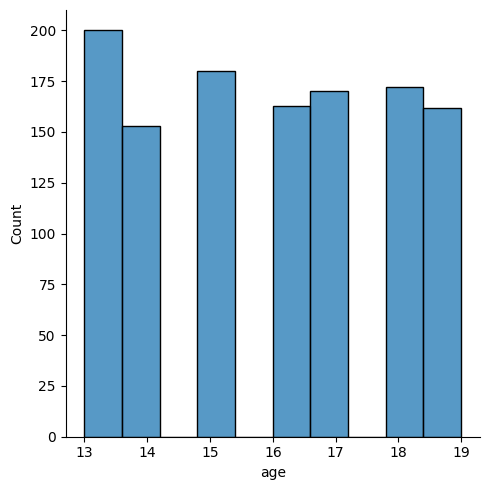

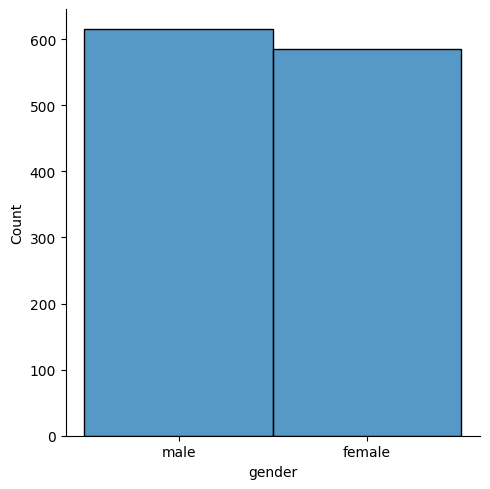

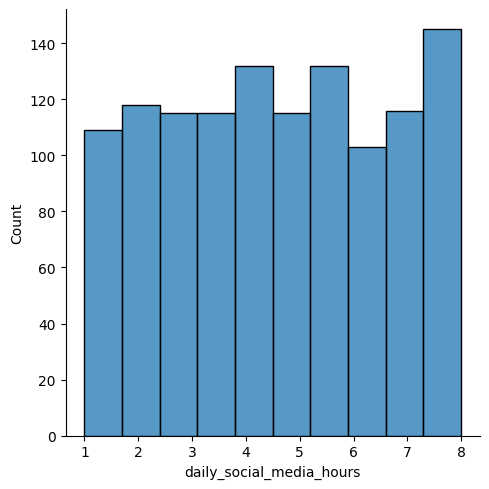

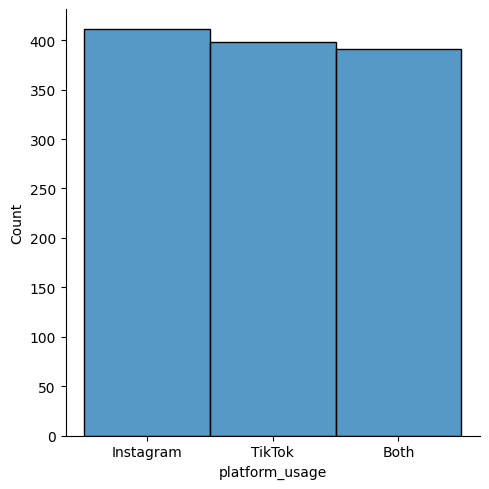

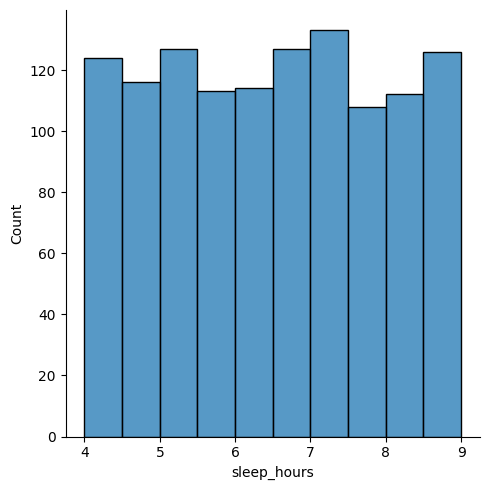

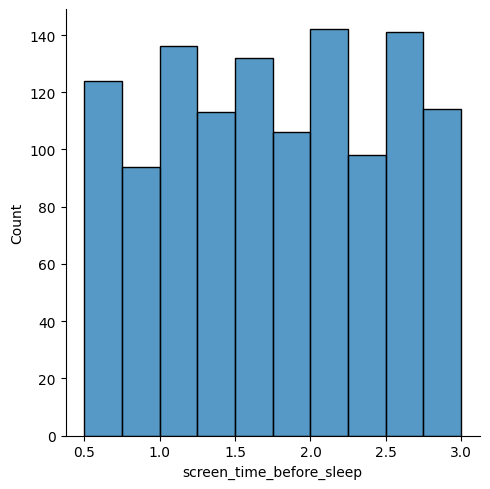

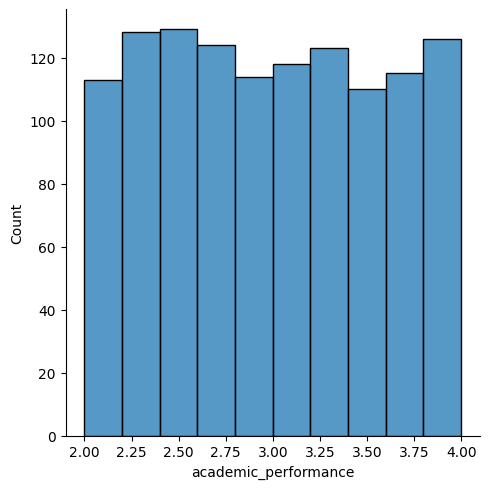

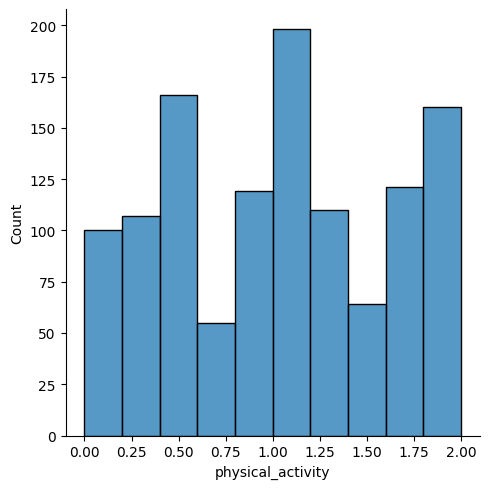

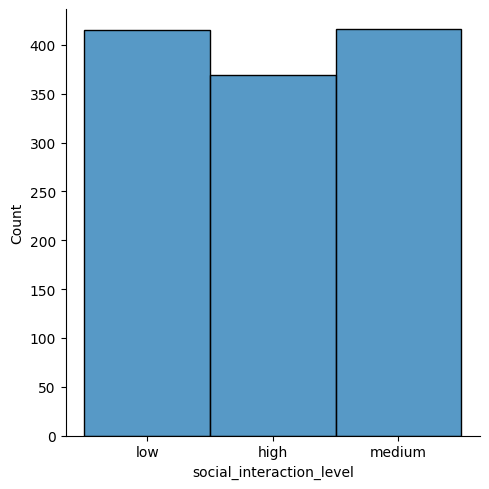

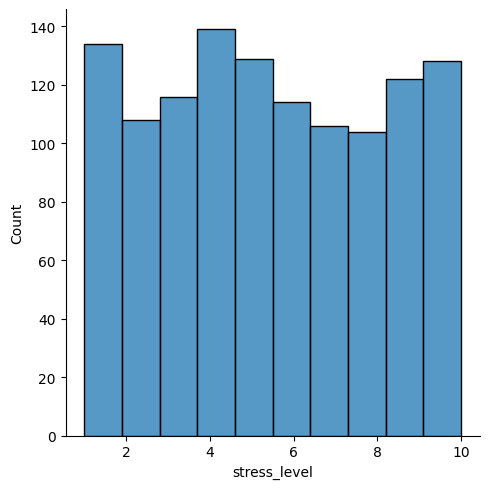

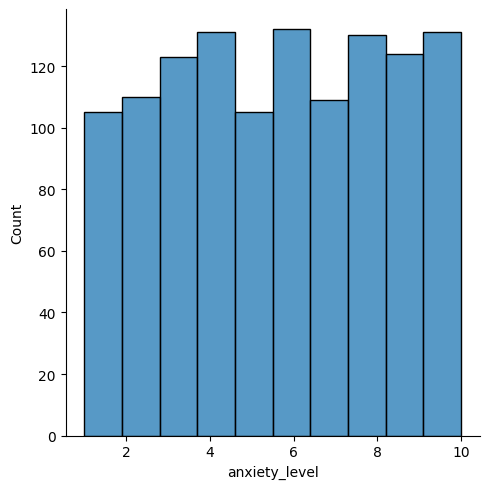

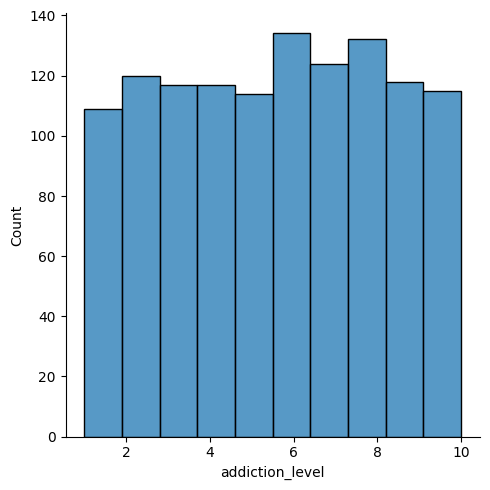

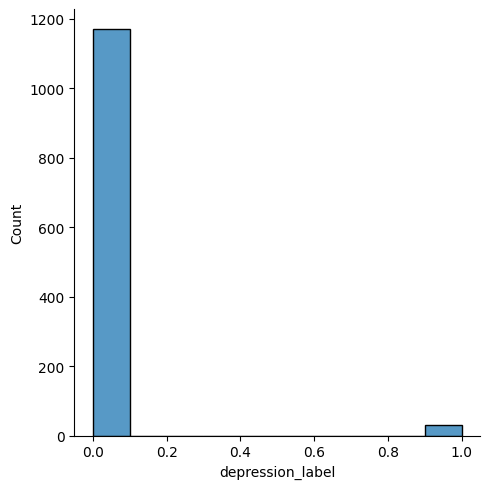

In [22]:
for i in df.columns:
    sns.displot(df[i], bins=10, kde=False)
    plt.show()

## Data Preprocessing

In [23]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

le_gender = LabelEncoder()
df['gender'] = le_gender.fit_transform(df['gender'])

social_mapping = {'low': 0, 'medium': 1, 'high': 2}
df['social_interaction_level'] = df['social_interaction_level'].map(social_mapping)

df = pd.get_dummies(df, columns=['platform_usage'], prefix='platform')

features_to_scale = ['age', 'daily_social_media_hours', 'sleep_hours', 'screen_time_before_sleep', 
                     'academic_performance', 'physical_activity', 'stress_level', 
                     'anxiety_level', 'addiction_level']

scaler = StandardScaler()
df[features_to_scale] = scaler.fit_transform(df[features_to_scale])

df.head()

,age,gender,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label,platform_Both,platform_Instagram,platform_TikTok
0,-0.954099,1,1.657833,0.659177,1.618830,0.034026,0.834276,0,-1.187367,-1.272335,-1.613389,0,0,1,0
1,1.519796,0,-1.299649,1.075244,1.618830,0.398282,-0.368593,2,0.880116,-1.622199,1.567444,0,0,0,1
2,0.530238,0,-1.595397,0.797866,-1.731436,1.612470,-1.743301,2,-1.187367,-0.572609,-1.259963,0,0,1,0
3,-0.459320,1,1.411376,0.312455,-0.195897,0.849266,-0.368593,1,-1.531947,0.476980,1.214018,0,0,0,1
4,-0.459320,0,0.080509,-1.074435,1.758424,-1.076088,0.662437,1,-0.842786,-0.222746,-1.259963,0,1,0,0


## Correlation Analysis

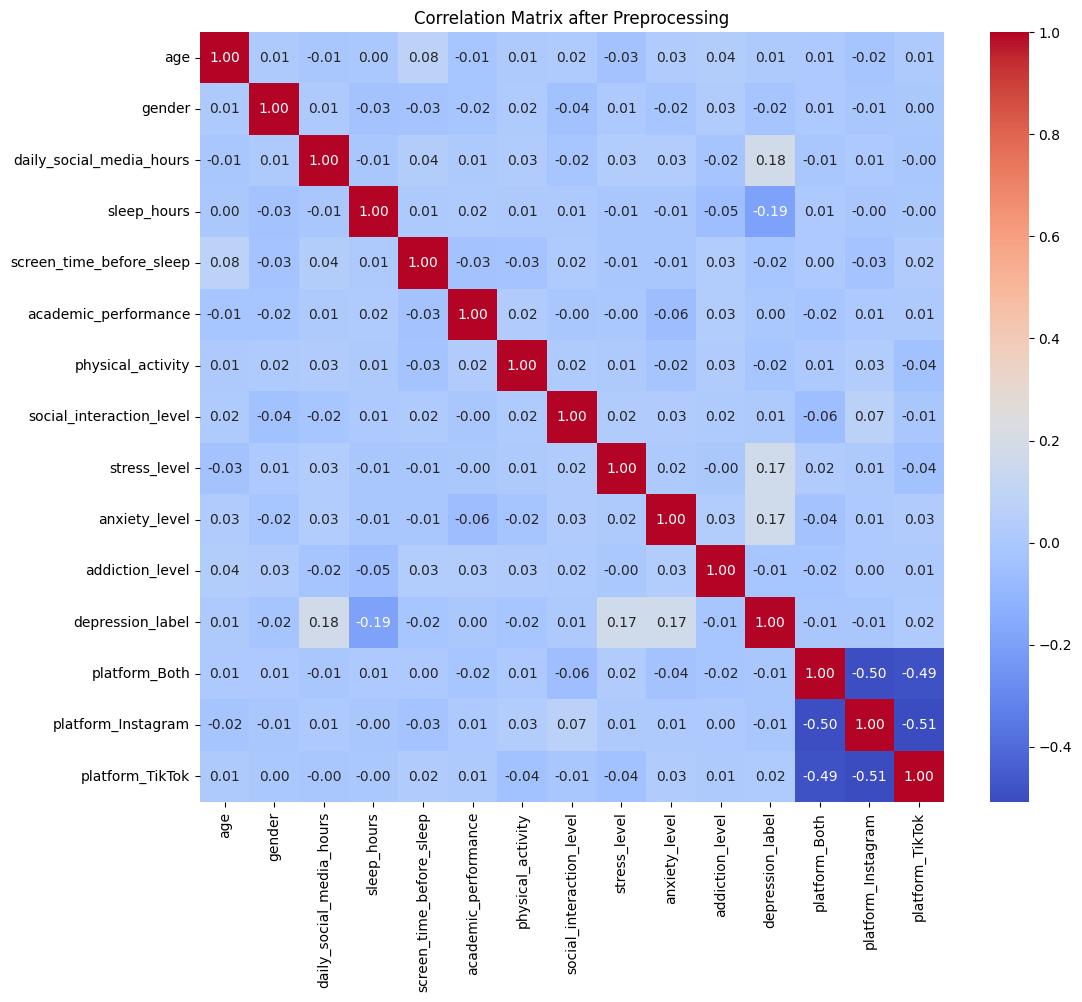

In [24]:
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix after Preprocessing')
plt.show()

## Data Cleaning

In [25]:
print("Jumlah Missing Values:\n", df.isnull().sum())

duplicate_count = df.duplicated().sum()
print(f"\nJumlah Data Duplikat: {duplicate_count}")
if duplicate_count > 0:
    df = df.drop_duplicates()
    print("Duplikat telah dihapus.")

numerical_cols = ['age', 'daily_social_media_hours', 'sleep_hours', 'screen_time_before_sleep', 
                  'academic_performance', 'physical_activity', 'stress_level', 
                  'anxiety_level', 'addiction_level']

for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    if not outliers.empty:
        print(f"Outliers terdeteksi di kolom {col}: {len(outliers)} baris")

print("\nProses Data Cleaning Selesai.")

Jumlah Missing Values:
 age                         0
gender                      0
daily_social_media_hours    0
sleep_hours                 0
screen_time_before_sleep    0
academic_performance        0
physical_activity           0
social_interaction_level    0
stress_level                0
anxiety_level               0
addiction_level             0
depression_label            0
platform_Both               0
platform_Instagram          0
platform_TikTok             0
dtype: int64

Jumlah Data Duplikat: 0

Proses Data Cleaning Selesai.


# Data Modeling


## Train/Test Split

In [ ]:
from sklearn.model_selection import train_test_split

# Memisahkan fitur (X) dan target (y)
X = df.drop('depression_label', axis=1)
y = df['depression_label']

print(f'Jumlah fitur: {X.shape[1]}')
print(f'Fitur: {list(X.columns)}')
print(f'\nDistribusi target:')
print(y.value_counts())

# Split data: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'\nUkuran data training: {X_train.shape[0]}')
print(f'Ukuran data testing: {X_test.shape[0]}')
print(f'\nDistribusi target (training):')
print(y_train.value_counts())
print(f'\nDistribusi target (testing):')
print(y_test.value_counts())

## Model 1: Random Forest Classifier

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Inisialisasi dan training model Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2
)

rf_model.fit(X_train, y_train)

# Prediksi pada data testing
y_pred_rf = rf_model.predict(X_test)

# Evaluasi model
rf_accuracy = accuracy_score(y_test, y_pred_rf)
print('=== Random Forest Classifier ===')
print(f'Accuracy: {rf_accuracy:.4f}')
print(f'\nClassification Report:')
print(classification_report(y_test, y_pred_rf, target_names=['Tidak Depresi (0)', 'Depresi (1)']))

# Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Tidak Depresi', 'Depresi'],
            yticklabels=['Tidak Depresi', 'Depresi'])
plt.title('Confusion Matrix - Random Forest')
plt.ylabel('Aktual')
plt.xlabel('Prediksi')
plt.tight_layout()
plt.show()

## Model 2: Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression

# Inisialisasi dan training model Logistic Regression
lr_model = LogisticRegression(
    random_state=42,
    max_iter=1000,
    solver='lbfgs'
)

lr_model.fit(X_train, y_train)

# Prediksi pada data testing
y_pred_lr = lr_model.predict(X_test)

# Evaluasi model
lr_accuracy = accuracy_score(y_test, y_pred_lr)
print('=== Logistic Regression ===')
print(f'Accuracy: {lr_accuracy:.4f}')
print(f'\nClassification Report:')
print(classification_report(y_test, y_pred_lr, target_names=['Tidak Depresi (0)', 'Depresi (1)']))

# Confusion Matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Tidak Depresi', 'Depresi'],
            yticklabels=['Tidak Depresi', 'Depresi'])
plt.title('Confusion Matrix - Logistic Regression')
plt.ylabel('Aktual')
plt.xlabel('Prediksi')
plt.tight_layout()
plt.show()

## Model 3: Support Vector Machine (SVM)

In [ ]:
from sklearn.svm import SVC

# Inisialisasi dan training model SVM
svm_model = SVC(
    kernel='rbf',
    random_state=42,
    C=1.0,
    gamma='scale'
)

svm_model.fit(X_train, y_train)

# Prediksi pada data testing
y_pred_svm = svm_model.predict(X_test)

# Evaluasi model
svm_accuracy = accuracy_score(y_test, y_pred_svm)
print('=== Support Vector Machine (SVM) ===')
print(f'Accuracy: {svm_accuracy:.4f}')
print(f'\nClassification Report:')
print(classification_report(y_test, y_pred_svm, target_names=['Tidak Depresi (0)', 'Depresi (1)']))

# Confusion Matrix
cm_svm = confusion_matrix(y_test, y_pred_svm)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Tidak Depresi', 'Depresi'],
            yticklabels=['Tidak Depresi', 'Depresi'])
plt.title('Confusion Matrix - SVM')
plt.ylabel('Aktual')
plt.xlabel('Prediksi')
plt.tight_layout()
plt.show()

## Perbandingan Model

In [ ]:
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score

# Membuat tabel perbandingan model
model_names = ['Random Forest', 'Logistic Regression', 'SVM']
predictions = [y_pred_rf, y_pred_lr, y_pred_svm]
accuracies = [rf_accuracy, lr_accuracy, svm_accuracy]

comparison_data = []
for name, y_pred, acc in zip(model_names, predictions, accuracies):
    comparison_data.append({
        'Model': name,
        'Accuracy': f'{acc:.4f}',
        'Precision': f'{precision_score(y_test, y_pred):.4f}',
        'Recall': f'{recall_score(y_test, y_pred):.4f}',
        'F1-Score': f'{f1_score(y_test, y_pred):.4f}'
    })

comparison_df = pd.DataFrame(comparison_data)
print('=== Perbandingan Performa Model ===')
comparison_df

In [ ]:
# Visualisasi perbandingan akurasi model
fig, ax = plt.subplots(figsize=(10, 6))

colors = ['#3498db', '#e74c3c', '#2ecc71']
bars = ax.bar(model_names, accuracies, color=colors, edgecolor='black', linewidth=0.5)

# Menambahkan label nilai di atas setiap bar
for bar, acc in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
            f'{acc:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=12)

ax.set_title('Perbandingan Akurasi Model', fontsize=14, fontweight='bold')
ax.set_ylabel('Akurasi', fontsize=12)
ax.set_xlabel('Model', fontsize=12)
ax.set_ylim(0, 1.1)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## Feature Importance (Random Forest)

In [ ]:
# Analisis Feature Importance dari model Random Forest
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print('=== Feature Importance (Random Forest) ===')
print(feature_importance.to_string(index=False))

# Visualisasi Feature Importance
plt.figure(figsize=(12, 6))
sns.barplot(data=feature_importance, x='Importance', y='Feature',
            palette='viridis')
plt.title('Feature Importance - Random Forest', fontsize=14, fontweight='bold')
plt.xlabel('Importance', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.tight_layout()
plt.show()

## Kesimpulan

Dari hasil modeling di atas, dapat disimpulkan:

1. **Train/Test Split**: Dataset dibagi menjadi 80% data training dan 20% data testing dengan stratified sampling untuk menjaga distribusi kelas yang seimbang.

2. **Model yang Digunakan**: Tiga model klasifikasi telah dilatih dan dievaluasi:
   - Random Forest Classifier
   - Logistic Regression
   - Support Vector Machine (SVM)

3. **Evaluasi**: Setiap model dievaluasi menggunakan metrik accuracy, precision, recall, dan F1-score.

4. **Feature Importance**: Analisis feature importance dari Random Forest menunjukkan fitur-fitur yang paling berpengaruh dalam prediksi label depresi pada remaja.